# 미션 16 Inference Part

- 기본 모델: `ahnhs2k/qtranslator_1.7b_v2`(Qwen3 1.7B 기반 한일 번역 자체 훈련 모델)
- 링크: [허깅페이스 모델 카드](https://huggingface.co/ahnhs2k/qtranslator_1.7b_v2)
- 목표 산출물
  - `qtranslator_1.7b_v2.pth`
  - `qtranslator_1.7b_v2_quantized.pth`
  - `qtranslator_1.7b_v2.onnx`
- 검증: PyTorch/ONNX 추론 결과 비교 + 간단 평가 데이터셋 성능 확인

## 1) 환경 준비

In [1]:
# 라이브러리 임포트
import os
import json
import time
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

import gc
import onnx
import onnxruntime as ort
from transformers import AutoTokenizer, AutoModelForCausalLM


## 2) 환경 설정

In [2]:
# 기본 환경 설정
@dataclass
class Config:
    # 모델과 결과물 저장 경로 설정
    project_dir = Path.cwd().parent
    model_dir = project_dir / "models" / "qtranslator_1.7b_v2"
    output_dir = project_dir / "models" / "m16"

    model_repo = "ahnhs2k/qtranslator_1.7b_v2"
    model_name = "qtranslator_1.7b_v2"

    # 미션 제출 규칙 mission_16_{model_name}.pth / .onnx로 저장
    pth_path = output_dir / f"mission_16_{model_name}.pth"
    pth_quant_path = output_dir / f"mission_16_{model_name}_quantized.pth"
    onnx_path = output_dir / f"mission_16_{model_name}.onnx"

    # 시드 고정
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # 디바이스 설정: 형식별 시간 비교를 위해 CPU로 통일
    device = "cpu"

    def __post_init__(self):
        self.model_dir.parent.mkdir(parents=True, exist_ok=True)
        self.output_dir.mkdir(parents=True, exist_ok=True)


In [3]:
cfg = Config()
print("device:", cfg.device)
print("model_dir:", cfg.model_dir)
print("output_dir:", cfg.output_dir)
print("pth:", cfg.pth_path)
print("pth_quant:", cfg.pth_quant_path)
print("onnx:", cfg.onnx_path)


device: cpu
model_dir: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/qtranslator_1.7b_v2
output_dir: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16
pth: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16/mission_16_qtranslator_1.7b_v2.pth
pth_quant: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16/mission_16_qtranslator_1.7b_v2_quantized.pth
onnx: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16/mission_16_qtranslator_1.7b_v2.onnx


## 3) 모델/토크나이저 로드 (HF baseline)

In [4]:
# 모델과 토크나이저 로드 (CPU 기준)
tokenizer = AutoTokenizer.from_pretrained(cfg.model_dir, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    cfg.model_dir,
    torch_dtype=torch.float32,
    trust_remote_code=True,
).to(cfg.device)
model.eval()

The tokenizer you are loading from '/home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/qtranslator_1.7b_v2' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (post_attention_layer

## 4) ONNX 체크

In [5]:
# ONNX 모델 로드 및 유효성 검증
onnx_model = onnx.load(cfg.onnx_path.as_posix())
onnx.checker.check_model(cfg.onnx_path.as_posix())
print("ONNX check: OK")


ONNX check: OK


## 5) 공통 함수 정의

In [6]:
# 번역 추론용 유틸 함수
def build_prompt(instruction: str, user_input: str) -> str:
    """번역용 입력을 Instruction/Input/Output 프롬프트로 포맷팅한다.

    Args:
        instruction: 모델에게 줄 작업 지시문.
        user_input: 실제 번역 대상 원문.

    Returns:
        str: `### Instruction/### Input/### Output` 블록 형식의 프롬프트 문자열.
    """
    instruction = (instruction or "").strip()
    user_input = (user_input or "").strip()

    return (
        "### Instruction:\n"
        f"{instruction}\n\n"
        "### Input:\n"
        f"{user_input}\n\n"
        "### Output:\n"
    )


def extract_output_text(generated_text: str) -> str:
    """
    생성 결과에서 "### Output:" 이후만 안전하게 뽑는다.
    (프롬프트를 통째로 echo 하거나, 앞부분이 섞여도 대응)
    """
    marker = "### Output:\n"
    if marker in generated_text:
        return generated_text.split(marker, 1)[1].strip()

    marker2 = "### Output:"
    if marker2 in generated_text:
        return generated_text.split(marker2, 1)[1].strip()

    return generated_text.strip()


In [7]:
# pth 모델들 로드 함수 정의
def load_model_from_pth():
    """저장된 일반 `.pth` 체크포인트에서 PyTorch 모델을 복원한다.

    Returns:
        PreTrainedModel: `cfg.pth_path`의 `state_dict`를 로드한 eval 모드 모델.
    """
    ckpt = torch.load(cfg.pth_path, map_location="cpu")
    loaded = AutoModelForCausalLM.from_pretrained(
        cfg.model_dir,
        torch_dtype=torch.float32,
        trust_remote_code=True,
    )
    loaded.load_state_dict(ckpt["state_dict"], strict=True)
    loaded.to(cfg.device)
    loaded.eval()
    return loaded


def load_quantized_model_from_pth():
    """저장된 양자화 `.pth` 체크포인트에서 동적 양자화 모델을 복원한다.

    Returns:
        PreTrainedModel: `nn.Linear`에 int8 동적 양자화를 적용한 eval 모드 모델.
    """
    ckpt = torch.load(cfg.pth_quant_path, map_location="cpu")

    base = AutoModelForCausalLM.from_pretrained(
        cfg.model_dir,
        torch_dtype=torch.float32,
        trust_remote_code=True,
    )
    q_model = torch.quantization.quantize_dynamic(
        base,
        {nn.Linear},
        dtype=torch.qint8,
    )
    q_model.load_state_dict(ckpt["state_dict"], strict=True)
    q_model.eval()
    return q_model


In [8]:
def torch_greedy_generate_with_model(model_obj, prompt: str, max_new_tokens: int = 80):
    """PyTorch 모델(일반/재로딩/양자화 공통)로 Greedy 디코딩을 수행한다.

    Args:
        model_obj: `generate()`를 지원하는 Hugging Face CausalLM 모델 객체.
        prompt: `build_prompt()`로 만든 입력 프롬프트 문자열.
        max_new_tokens: 생성할 최대 신규 토큰 수.

    Returns:
        str: 후처리(`extract_output_text`)가 적용된 최종 번역 텍스트.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(cfg.device)
    with torch.no_grad():
        out = model_obj.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
        )

        jp_text = tokenizer.decode(out[0], skip_special_tokens=True)
        jp = extract_output_text(jp_text)
    return jp


def evaluate_torch_variant(variant_name, model_obj, eval_data, instruction, max_new_tokens=80):
    """PyTorch 계열 모델의 샘플별 예측 결과와 지연시간을 평가한다.

    Args:
        variant_name: 결과 테이블에 기록할 모델 변형 이름.
        model_obj: 평가할 PyTorch 모델 객체.
        eval_data: `[{"src": ..., "tgt": ...}, ...]` 형태의 평가 샘플 리스트.
        instruction: 프롬프트의 Instruction 문구.
        max_new_tokens: 샘플당 최대 생성 토큰 수.

    Returns:
        pd.DataFrame: 샘플별 입력/정답/예측/정답포함여부/소요시간(sec) 테이블.
    """
    rows = []
    for item in eval_data:
        prompt = build_prompt(instruction, item["src"])
        t0 = time.time()
        pred = torch_greedy_generate_with_model(model_obj, prompt, max_new_tokens=max_new_tokens)
        elapsed = time.time() - t0
        rows.append({
            "variant": variant_name,
            "src": item["src"],
            "ref": item["tgt"],
            "prompt": prompt,
            "pred": pred,
            "contains_ref": int(item["tgt"].lower() in pred.lower()),
            "sec": round(elapsed, 3),
        })
    return pd.DataFrame(rows)


In [9]:
def onnx_greedy_generate(session, prompt: str, max_new_tokens: int = 80):
    """ONNX Runtime 세션으로 Greedy 디코딩을 수행한다.

    Args:
        session: `onnxruntime.InferenceSession` 객체.
        prompt: `build_prompt()`로 만든 입력 프롬프트 문자열.
        max_new_tokens: 생성할 최대 신규 토큰 수.

    Returns:
        str: 후처리(`extract_output_text`)가 적용된 최종 번역 텍스트.
    """
    input_ids = tokenizer(prompt, return_tensors="np")["input_ids"].astype(np.int64)

    for _ in range(max_new_tokens):
        attention_mask = np.ones_like(input_ids, dtype=np.int64)
        logits = session.run(
            ["logits"],
            {
                "input_ids": input_ids,
                "attention_mask": attention_mask,
            },
        )[0]    # [B, T, V] 배치, 토큰, 어휘 수 차원

        # 마지막 토큰 위치만 사용해서 최고 점수 토큰 추출: shape [B, V] -> shape [B, 1]
        next_token = np.argmax(logits[:, -1, :], axis=-1, keepdims=True).astype(np.int64)
        input_ids = np.concatenate([input_ids, next_token], axis=1)

        if tokenizer.eos_token_id is not None and int(next_token[0, 0]) == tokenizer.eos_token_id:
            break

    jp_text = tokenizer.decode(input_ids[0], skip_special_tokens=True)
    jp = extract_output_text(jp_text)

    return jp


def evaluate_onnx_variant(variant_name, session, eval_data, instruction, max_new_tokens=80):
    """ONNX 모델의 샘플별 예측 결과와 지연시간을 평가한다.

    Args:
        variant_name: 결과 테이블에 기록할 모델 변형 이름.
        session: 평가할 ONNX Runtime 세션.
        eval_data: `[{"src": ..., "tgt": ...}, ...]` 형태의 평가 샘플 리스트.
        instruction: 프롬프트의 Instruction 문구.
        max_new_tokens: 샘플당 최대 생성 토큰 수.

    Returns:
        pd.DataFrame: 샘플별 입력/정답/예측/정답포함여부/소요시간(sec) 테이블.
    """
    rows = []
    for item in eval_data:
        prompt = build_prompt(instruction, item["src"])
        t0 = time.time()
        pred = onnx_greedy_generate(session, prompt, max_new_tokens=max_new_tokens)
        elapsed = time.time() - t0
        rows.append({
            "variant": variant_name,
            "src": item["src"],
            "ref": item["tgt"],
            "prompt": prompt,
            "pred": pred,
            "contains_ref": int(item["tgt"].lower() in pred.lower()),
            "sec": round(elapsed, 3),
        })
    return pd.DataFrame(rows)


## 6) 추론 실험 실행

In [10]:
# 평가 데이터셋 (한일 번역 샘플)
eval_data = [
    {"src": "트리시는 나 자신의 명령으로 호위한다!", "tgt": "トリッシュは俺自信の命令で護衛するッ！"},
    {"src": "오늘은 왠지 상태가 안 좋아.", "tgt": "今日はなんだか体調が悪いの。"},
    {"src": "이 비밀이 밝혀지면 모든 것이 달라질 거야. 하지만 넌 알아야 해.", "tgt": "この秘密が明らかになれば、すべてが変わるだろう。でも、君は知るべきだ。"},
    {"src": "나도 알아… 하지만 이 감정을 숨길 수가 없어.", "tgt": "私も分かってる…でもこの気持ちは隠せないの。"},
    {"src": "가끔은 이런 침묵도 나쁘지 않은 것 같아.", "tgt": "時々、こんな沈黙も悪くないと思う。"},
]

instruction_text = "다음 한국어 문장을 자연스러운 일본어로 번역하시오."

all_results = []

# 1) 일반 Hugging Face 모델
df_hf = evaluate_torch_variant("hf", model, eval_data, instruction_text)
all_results.append(df_hf)

# 2) .pth 재로딩 모델
model_pth = load_model_from_pth()
df_pth = evaluate_torch_variant("pth", model_pth, eval_data, instruction_text)
all_results.append(df_pth)
del model_pth
gc.collect()

# 3) .pth(양자화) 재로딩 모델
model_pth_q = load_quantized_model_from_pth()
df_pth_q = evaluate_torch_variant("pth_quant", model_pth_q, eval_data, instruction_text)
all_results.append(df_pth_q)
del model_pth_q
gc.collect()

# 4) ONNX 모델
ort_session = ort.InferenceSession(
    cfg.onnx_path.as_posix(),
    providers=["CPUExecutionProvider"],
)
df_onnx = evaluate_onnx_variant("onnx", ort_session, eval_data, instruction_text)
all_results.append(df_onnx)

# 샘플별 상세 결과
result_df = pd.concat(all_results, ignore_index=True)
result_df


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
/home/hosung/pytorch-demo/Mission_Archive/.venv/lib/python3.11/site-packages/torch/_utils.py:455: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  device=storage.device,


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

/tmp/ipykernel_58878/1073374194.py:33: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  q_model = torch.quantization.quantize_dynamic(
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id`

,variant,src,ref,prompt,pred,contains_ref,sec
0,hf,트리시는 나 자신의 명령으로 호위한다!,トリッシュは俺自信の命令で護衛するッ！,### Instruction:\n다음 한국어 문장을 자연스러운 일본어로 번역하시오....,トリシは自分の命令で護りつける！,0,2.065
1,hf,오늘은 왠지 상태가 안 좋아.,今日はなんだか体調が悪いの。,### Instruction:\n다음 한국어 문장을 자연스러운 일본어로 번역하시오....,今日はなんだか体調が悪い。,0,1.257
2,hf,이 비밀이 밝혀지면 모든 것이 달라질 거야. 하지만 넌 알아야 해.,この秘密が明らかになれば、すべてが変わるだろう。でも、君は知るべきだ。,### Instruction:\n다음 한국어 문장을 자연스러운 일본어로 번역하시오....,この秘密が明かされればすべてが変わる。でも君は知るべきだ。,0,2.523
3,hf,나도 알아… 하지만 이 감정을 숨길 수가 없어.,私も分かってる…でもこの気持ちは隠せないの。,### Instruction:\n다음 한국어 문장을 자연스러운 일본어로 번역하시오....,私もわかってる…でもこの感情を隠せないの。,0,2.044
4,hf,가끔은 이런 침묵도 나쁘지 않은 것 같아.,時々、こんな沈黙も悪くないと思う。,### Instruction:\n다음 한국어 문장을 자연스러운 일본어로 번역하시오....,たまにはこんな沈黙も悪くないと思う。,0,1.989
5,pth,트리시는 나 자신의 명령으로 호위한다!,トリッシュは俺自信の命令で護衛するッ！,### Instruction:\n다음 한국어 문장을 자연스러운 일본어로 번역하시오....,トリシは自分の命令で護りつける！,0,1.722
6,pth,오늘은 왠지 상태가 안 좋아.,今日はなんだか体調が悪いの。,### Instruction:\n다음 한국어 문장을 자연스러운 일본어로 번역하시오....,今日はなんだか体調が悪い。,0,1.263
7,pth,이 비밀이 밝혀지면 모든 것이 달라질 거야. 하지만 넌 알아야 해.,この秘密が明らかになれば、すべてが変わるだろう。でも、君は知るべきだ。,### Instruction:\n다음 한국어 문장을 자연스러운 일본어로 번역하시오....,この秘密が明かされればすべてが変わる。でも君は知るべきだ。,0,2.627
8,pth,나도 알아… 하지만 이 감정을 숨길 수가 없어.,私も分かってる…でもこの気持ちは隠せないの。,### Instruction:\n다음 한국어 문장을 자연스러운 일본어로 번역하시오....,私もわかってる…でもこの感情を隠せないの。,0,1.967
9,pth,가끔은 이런 침묵도 나쁘지 않은 것 같아.,時々、こんな沈黙も悪くないと思う。,### Instruction:\n다음 한국어 문장을 자연스러운 일본어로 번역하시오....,たまにはこんな沈黙も悪くないと思う。,0,1.808


## 7) 요약 및 시간 비교

In [11]:
# 방식별 요약 지표(정확도/평균 추론 시간)
summary_df = (
    result_df.groupby("variant", as_index=False)
    .agg(
        avg_sec=("sec", "mean"),
        min_sec=("sec", "min"),
        max_sec=("sec", "max"),
    )
    .sort_values("avg_sec")
)
summary_df


,variant,avg_sec,min_sec,max_sec
3,pth_quant,0.8936,0.587,1.109
2,pth,1.8774,1.263,2.627
0,hf,1.9756,1.257,2.523
1,onnx,3.3624,1.885,5.333


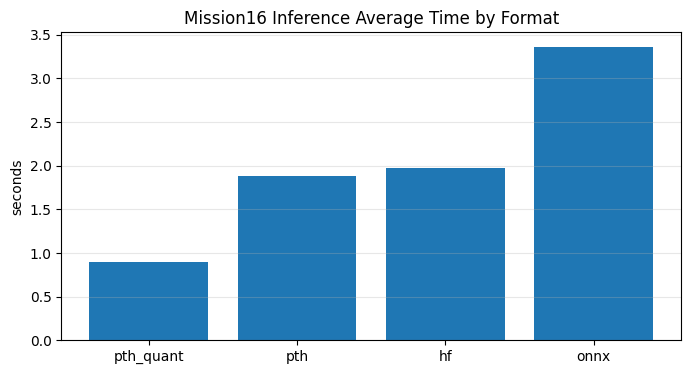

Saved image: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16/mission16_inference_avg_time.png


In [12]:
plt.figure(figsize=(8, 4))
plt.bar(summary_df["variant"], summary_df["avg_sec"])
plt.title("Mission16 Inference Average Time by Format")
plt.ylabel("seconds")
plt.grid(axis="y", alpha=0.3)

infer_image_path = cfg.output_dir / "mission16_inference_avg_time.png"
plt.savefig(infer_image_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved image:", infer_image_path)
